In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
print("All libraries imported successfully!")

All libraries imported successfully!


In [47]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Gauri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [48]:
df=pd.read_csv("DATA/tech_job_market_2019_2026.csv")

In [49]:
df.shape

(115000, 28)

In [50]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [51]:
df.dtypes

job_id                              str
company_name                        str
company_type                        str
sector                              str
company_size_employees            int64
hq_country                          str
job_role                            str
seniority_level                     str
years_experience_min              int64
years_experience_max              int64
required_tech_stack                 str
primary_programming_language        str
work_mode                           str
visa_sponsorship_offered            str
job_location_country                str
job_location_city                   str
salary_currency                     str
posting_date                        str
application_deadline                str
date_position_filled                str
position_status                     str
number_of_applicants            float64
number_of_interview_rounds      float64
offers_extended                 float64
offers_accepted                 float64


In [52]:
# Check all columns before selecting the target
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [53]:
df["salary_min_usd"] = pd.to_numeric(
    df["salary_min_usd"], errors="coerce"
)

In [54]:
df["salary_max_usd"] = pd.to_numeric(
    df["salary_max_usd"], errors="coerce"
)

In [55]:
df["expected_salary"] = (
    df["salary_min_usd"] + df["salary_max_usd"]
) / 2

In [56]:
df[[
    "salary_min_usd",
    "salary_max_usd",
    "expected_salary"
]].head()

,salary_min_usd,salary_max_usd,expected_salary
0,-1.0,-1.0,-1.0
1,NaN,NaN,NaN
2,238800.0,274700.0,256750.0
3,96300.0,104000.0,100150.0
4,NaN,245400.0,NaN


In [57]:
df[[
    "salary_min_usd",
    "salary_max_usd",
    "expected_salary"
]].isnull().sum()

salary_min_usd     5388
salary_max_usd     4004
expected_salary    5388
dtype: int64

In [58]:
df = df.dropna(subset=["expected_salary"])

In [59]:
y = df["expected_salary"]

In [60]:
X = df.drop(
    columns=[
        "expected_salary",
        "salary_min_usd",
        "salary_max_usd"
    ]
)

In [61]:
X = X.drop(columns=["job_id"], errors="ignore")

In [62]:
X = X.drop(
    columns=["job_id", "company_name"],
    errors="ignore"
)

In [63]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns

print("Numerical features:")
print(list(numerical_columns))

print("\nCategorical features:")
print(list(categorical_columns))

Numerical features:
['company_size_employees', 'years_experience_min', 'years_experience_max', 'number_of_applicants', 'number_of_interview_rounds', 'offers_extended', 'offers_accepted']

Categorical features:
['company_type', 'sector', 'hq_country', 'job_role', 'seniority_level', 'required_tech_stack', 'primary_programming_language', 'work_mode', 'visa_sponsorship_offered', 'job_location_country', 'job_location_city', 'salary_currency', 'posting_date', 'application_deadline', 'date_position_filled', 'position_status', 'layoff_within_12_months_flag']


C:\Users\Gauri\AppData\Local\Temp\ipykernel_27652\1564828391.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [65]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87689, 24)
X_test shape: (21923, 24)
y_train shape: (87689,)
y_test shape: (21923,)


In [66]:
# Step 7: Separate numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(list(numeric_features))

print("\nCategorical columns:")
print(list(categorical_features))

Numerical columns:
['company_size_employees', 'years_experience_min', 'years_experience_max', 'number_of_applicants', 'number_of_interview_rounds', 'offers_extended', 'offers_accepted']

Categorical columns:
['company_type', 'sector', 'hq_country', 'job_role', 'seniority_level', 'required_tech_stack', 'primary_programming_language', 'work_mode', 'visa_sponsorship_offered', 'job_location_country', 'job_location_city', 'salary_currency', 'posting_date', 'application_deadline', 'date_position_filled', 'position_status', 'layoff_within_12_months_flag']


C:\Users\Gauri\AppData\Local\Temp\ipykernel_27652\2136505618.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# For numerical columns
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# For categorical columns
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [69]:
from sklearn.linear_model import LinearRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [70]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['company_type','sector','company_size_employees',...,'offers_extended', 'offers_accepted','layoff_within_12_months_flag']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will 

In [71]:
y_pred = model.predict(X_test)

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 23715.036326241385
MSE : 1603128590.6380157
RMSE: 40039.088284300575
R²  : 0.6563860570902205


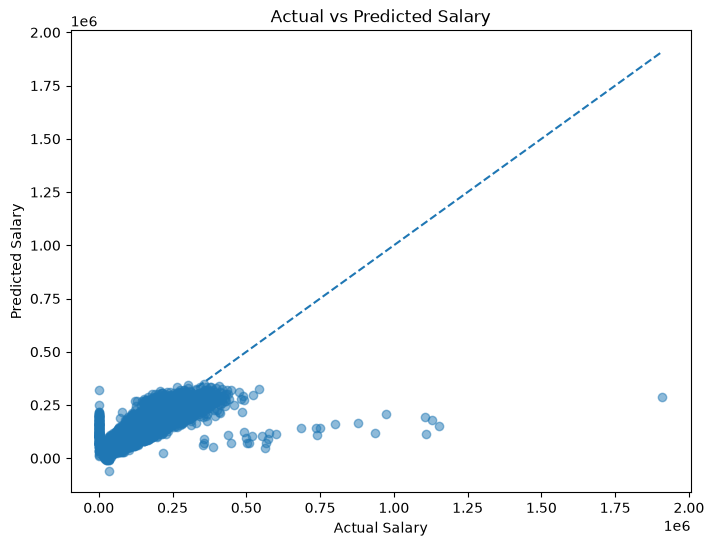

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()